# Laboratorio 4, Parte 2 — Modelos con datos geoespaciales

Cianobacteria en lagos Atitlán y Amatitlán. Este notebook parte de los rasters de la Parte I, data/atitlan y data/amatitlan, 9 bandas Sentinel-2 por fecha, y construye el conjunto de datos y los modelos de Machine Learning para clasificar zonas de alta y baja presencia de cianobacteria.

In [1]:
import glob
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform as warp_transform

DATA_DIR = Path("data")

ZONAS = {
    "atitlan": DATA_DIR / "atitlan",
    "amatitlan": DATA_DIR / "amatitlan",
}

# Mismo orden de bandas usado al descargar en la Parte I
BANDAS_TOTAL = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
IDX = {nombre: i + 1 for i, nombre in enumerate(BANDAS_TOTAL)}
print("Mapa de índices de bandas:", IDX)

Mapa de índices de bandas: {'B02': 1, 'B03': 2, 'B04': 3, 'B05': 4, 'B07': 5, 'B08': 6, 'B8A': 7, 'B11': 8, 'B12': 9}


## Ejercicio 1.1

Cada fila del dataset debe representar una observación geográfica válida, un píxel, dentro de un lago, en una fecha dada. Por cada archivo tif, leemos las 9 bandas, calculamos NDVI, NDWI y el índice de cianobacteria, mismas fórmulas de la Parte I, y obtenemos las coordenadas de cada píxel con rasterio.transform.xy.

NDVI es B08 menos B04, dividido entre B08 más B04.
NDWI es B03 menos B08, dividido entre B03 más B08.
CYANO es B05 menos B04, dividido entre B05 más B04.

Guardamos tanto las coordenadas nativas del raster, x, y, en el CRS del archivo tif, como lon y lat en WGS84, porque el Ejercicio 6 de más adelante pide reproyectar a UTM y es más seguro partir de las coordenadas nativas que reproyectar dos veces.

In [2]:
def extraer_fecha(nombre_archivo: str) -> str:
    match = re.search(r"(\d{4}-\d{2}-\d{2})", nombre_archivo)
    return match.group(1) if match else None


def raster_a_dataframe(ruta_tif: str, lago: str) -> pd.DataFrame:
    """Convierte un raster multibanda (una fecha, un lago) en una tabla de píxeles."""
    fecha = extraer_fecha(os.path.basename(ruta_tif))

    with rasterio.open(ruta_tif) as src:
        bandas = {nombre: src.read(IDX[nombre]).astype("float32") for nombre in BANDAS_TOTAL}
        transform = src.transform
        crs = src.crs
        shape = src.shape
        nodata = src.nodata

    filas, cols = np.indices(shape)
    xs, ys = rasterio.transform.xy(transform, filas.ravel(), cols.ravel())
    xs, ys = np.asarray(xs), np.asarray(ys)

    if crs and not crs.is_geographic:
        lons, lats = warp_transform(crs, "EPSG:4326", xs, ys)
        lons, lats = np.asarray(lons), np.asarray(lats)
    else:
        lons, lats = xs, ys

    datos = {nombre.lower(): banda.ravel() for nombre, banda in bandas.items()}

    with np.errstate(divide="ignore", invalid="ignore"):
        b04, b08 = datos["b04"], datos["b08"]
        b03 = datos["b03"]
        b05 = datos["b05"]
        ndvi = (b08 - b04) / (b08 + b04)
        ndwi = (b03 - b08) / (b03 + b08)
        cyano = (b05 - b04) / (b05 + b04)

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "x": xs,
        "y": ys,
        "lon": lons,
        "lat": lats,
        **datos,
        "ndvi": ndvi,
        "ndwi": ndwi,
        "cyano": cyano,
    })

    if nodata is not None:
        col_bandas = [nombre.lower() for nombre in BANDAS_TOTAL]
        es_nodata = (df[col_bandas] == nodata).any(axis=1)
        df.loc[es_nodata, col_bandas + ["ndvi", "ndwi", "cyano"]] = np.nan

    df["crs_nativo"] = str(crs)
    return df

## Ejercicio 1.3

El bounding box de descarga de la Parte I es rectangular y abarca tierra alrededor de cada lago, así que hay que recortar a los píxeles que sí son agua. Decisiones:

- Máscara de agua: NDWI mayor a 0, umbral estándar de McFeeters 1996 para delimitar cuerpos de agua con NDWI verde-NIR, misma fórmula que ya usamos en la Parte I. Todo lo que quede en o por debajo de 0 se descarta por ser tierra, vegetación u orilla.
- NoData, NaN e inf: se descartan filas con cualquier banda, NDVI, NDWI o cyano inválido, ya vienen como NaN desde raster_a_dataframe cuando el píxel es NoData.
- Nubes: la Parte I no descargó la banda de máscara de nubes SCL, así que no hay una forma directa de identificar nubes. Como aproximación, se descartan píxeles con reflectancia en B02, azul, por encima del percentil 99 dentro de cada imagen, las nubes y neblina suelen verse como reflectancia anómalamente alta y pareja en todas las bandas visibles. Esto es una heurística, no una detección real de nubes, se documenta como limitación en el 1.6 y sería mejor resolverlo re-descargando con la banda SCL.

In [3]:
def limpiar_dataframe(df: pd.DataFrame, umbral_ndwi: float = 0.0, percentil_nube: float = 99.0) -> pd.DataFrame:
    col_bandas = [nombre.lower() for nombre in BANDAS_TOTAL]
    columnas_clave = col_bandas + ["ndvi", "ndwi", "cyano"]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=columnas_clave)

    # Máscara de agua (McFeeters, 1996)
    df = df[df["ndwi"] > umbral_ndwi]

    # Heurística de nubes: reflectancia en B02 anómalamente alta, por fecha
    umbral_b02 = df.groupby("fecha")["b02"].transform(lambda s: np.percentile(s, percentil_nube))
    df = df[df["b02"] <= umbral_b02]

    return df.reset_index(drop=True)

In [4]:
def construir_dataset() -> pd.DataFrame:
    tablas = []
    for lago, carpeta in ZONAS.items():
        archivos = sorted(glob.glob(str(carpeta / "*.tif")))
        print(f"Procesando {lago}: {len(archivos)} archivos")
        for ruta_tif in archivos:
            try:
                df_crudo = raster_a_dataframe(ruta_tif, lago)
                df_limpio = limpiar_dataframe(df_crudo)
                tablas.append(df_limpio)
                print(f"  {os.path.basename(ruta_tif)}: {len(df_crudo)} px -> {len(df_limpio)} px válidos")
            except Exception as e:
                print(f"  [Error] {ruta_tif}: {e}")

    dataset = pd.concat(tablas, ignore_index=True)
    dataset["fecha"] = pd.to_datetime(dataset["fecha"])
    return dataset


dataset_ml = construir_dataset()
dataset_ml.to_parquet("dataset_ml_parte1.parquet", index=False)
print(f"\nDataset final: {dataset_ml.shape[0]} filas, {dataset_ml.shape[1]} columnas")
print("Guardado en dataset_ml_parte1.parquet")

Procesando atitlan: 11 archivos
  [Error] data\atitlan\atitlan_2025-01-18_bandas.tif: Read failed. See previous exception for details.


  atitlan_2025-04-13_bandas.tif: 4831009 px -> 1215255 px válidos


  atitlan_2025-05-13_bandas.tif: 4831009 px -> 1384766 px válidos


  atitlan_2025-07-17_bandas.tif: 4831009 px -> 1213246 px válidos


  atitlan_2025-11-21_bandas.tif: 4831009 px -> 1245188 px válidos


...

  amatitlan_2026-03-29_bandas.tif: 1247120 px -> 155031 px válidos


  amatitlan_2026-04-13_bandas.tif: 1247120 px -> 157075 px válidos


  amatitlan_2026-04-28_bandas.tif: 1247120 px -> 135357 px válidos


  amatitlan_2026-06-19_bandas.tif: 1247120 px -> 160726 px válidos



Dataset final: 13069970 filas, 19 columnas
Guardado en dataset_ml_parte1.parquet


## Ejercicio 1.4

Total de observaciones, conteo por lago, conteo por fecha, variables disponibles con su tipo, y porcentaje de valores faltantes.

In [5]:
print(f"Total de observaciones: {len(dataset_ml)}\n")

print("Observaciones por lago:")
print(dataset_ml["lago"].value_counts(), "\n")

print("Observaciones por fecha:")
print(dataset_ml.groupby(["lago", "fecha"]).size(), "\n")

print("Tipos de variables:")
print(dataset_ml.dtypes, "\n")

faltantes = dataset_ml.isna().mean().sort_values(ascending=False) * 100
print("Porcentaje de valores faltantes por columna:")
print(faltantes[faltantes > 0] if (faltantes > 0).any() else "Sin valores faltantes (ya se descartaron en la limpieza).")

Total de observaciones: 13069970

Observaciones por lago:


lago
atitlan      11422133
amatitlan     1647837
Name: count, dtype: int64 

Observaciones por fecha:


lago       fecha     
amatitlan  2025-01-28     156354
           2025-04-15     151406
           2025-04-28     147247
           2025-11-24     152815
           2026-01-08     141626
           2026-02-02     138374
           2026-02-07     151826
           2026-03-29     155031
           2026-04-13     157075
           2026-04-28     135357
           2026-06-19     160726
atitlan    2025-04-13    1215255
           2025-05-13    1384766
           2025-07-17    1213246
           2025-11-21    1245188
           2025-12-29    1380508
           2026-02-12    1192083
           2026-03-24    1246184
           2026-04-13    1212250
           2026-04-28    1332653
dtype: int64 

Tipos de variables:
lago                  object
fecha         datetime64[ns]
x                    float64
y                    float64
lon                  float64
lat                  float64
b02                  float32
b03                  float32
b04                  float32
b05                  f

Porcentaje de valores faltantes por columna:
Sin valores faltantes (ya se descartaron en la limpieza).


## Ejercicio 1.5

Histogramas de bandas e índices, boxplots por lago, y matriz de correlación entre las variables espectrales.

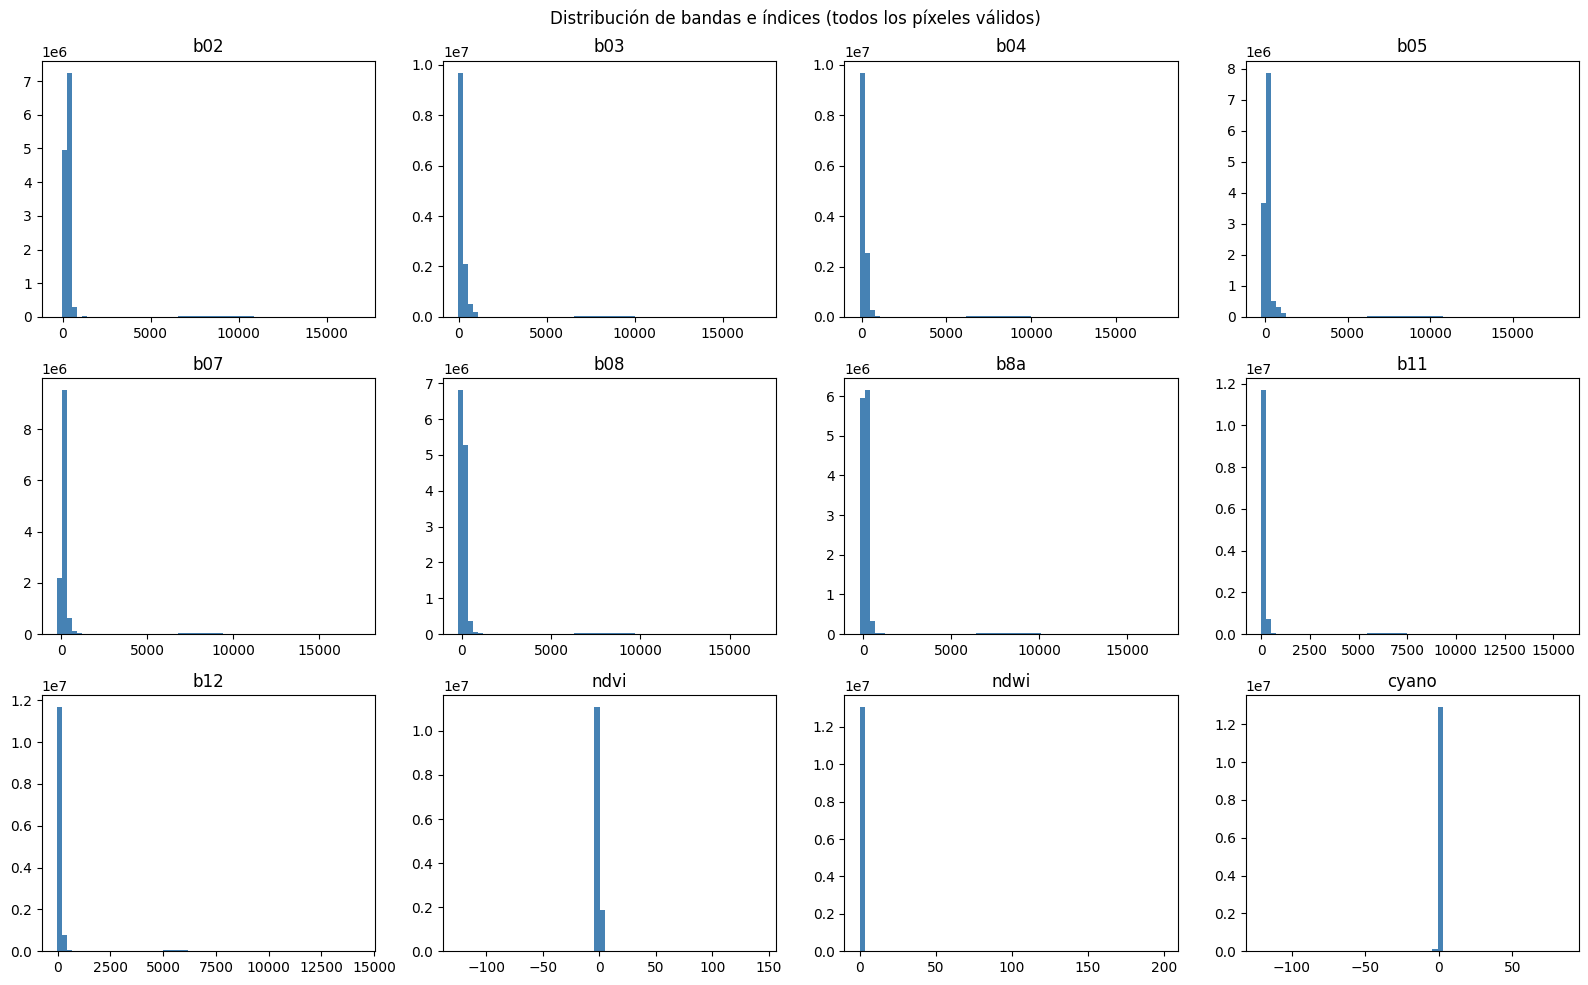

In [6]:
columnas_numericas = [nombre.lower() for nombre in BANDAS_TOTAL] + ["ndvi", "ndwi", "cyano"]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), columnas_numericas):
    ax.hist(dataset_ml[col], bins=60, color="steelblue")
    ax.set_title(col)
for ax in axes.ravel()[len(columnas_numericas):]:
    ax.axis("off")
fig.suptitle("Distribución de bandas e índices (todos los píxeles válidos)")
fig.tight_layout()
plt.savefig(DATA_DIR / "hist_variables_parte2.png", dpi=150)
plt.show()

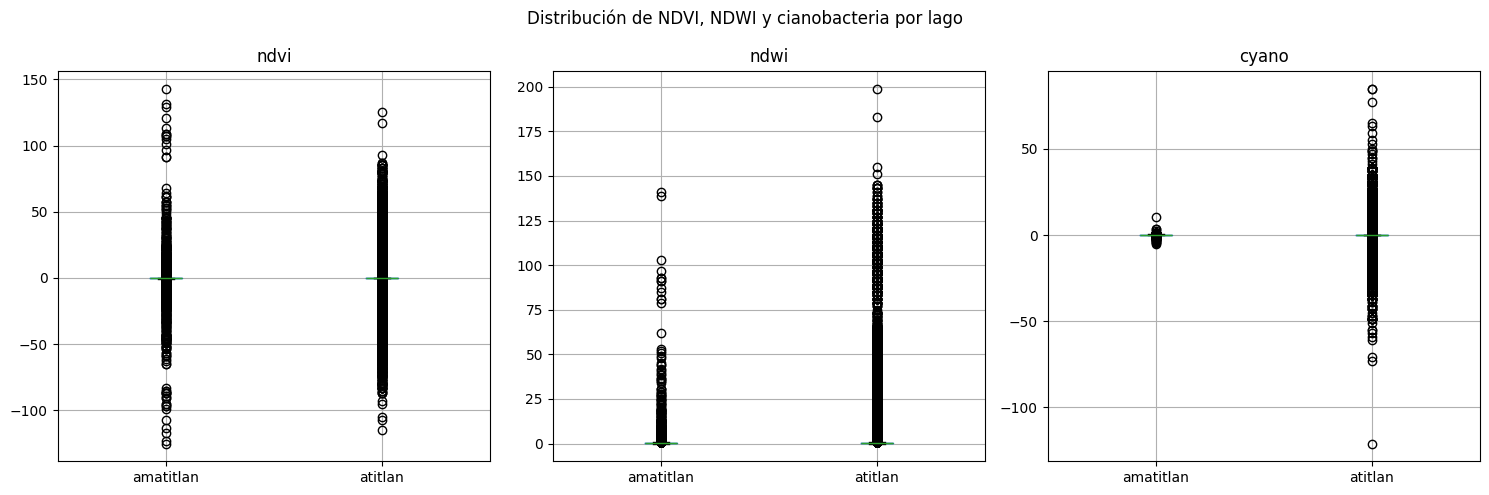

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["ndvi", "ndwi", "cyano"]):
    dataset_ml.boxplot(column=col, by="lago", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Distribución de NDVI, NDWI y cianobacteria por lago")
fig.tight_layout()
plt.savefig(DATA_DIR / "boxplot_variables_parte2.png", dpi=150)
plt.show()

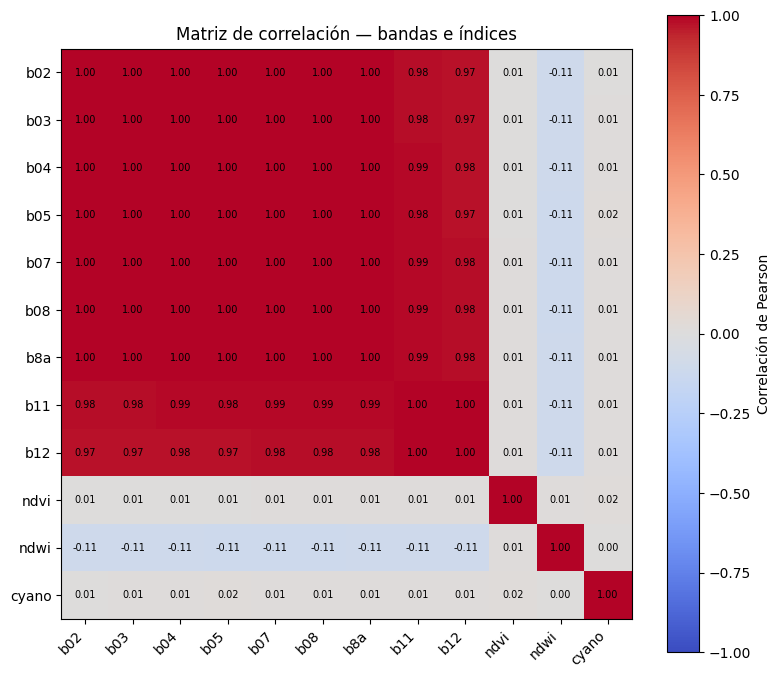

In [8]:
corr = dataset_ml[columnas_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_numericas)))
ax.set_xticklabels(columnas_numericas, rotation=45, ha="right")
ax.set_yticks(range(len(columnas_numericas)))
ax.set_yticklabels(columnas_numericas)
for i in range(len(columnas_numericas)):
    for j in range(len(columnas_numericas)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="Correlación de Pearson")
ax.set_title("Matriz de correlación — bandas e índices")
fig.tight_layout()
plt.savefig(DATA_DIR / "correlacion_variables_parte2.png", dpi=150)
plt.show()

## Ejercicio 1.6

Como grupo, tomamos las siguientes decisiones para preparar los datos:

- Trabajamos con cada píxel válido de las imágenes, tomando en cuenta la fecha y el lago al que pertenecía. Dejamos las bandas con el tamaño y la resolución originales.
- Guardamos las coordenadas x, y y también lon, lat. Decidimos guardar las dos porque algunos ejercicios necesitan las coordenadas en metros y otras veces es más práctico trabajar con longitud y latitud.
- Para separar el agua de la tierra, usamos la condición NDWI mayor a 0. Elegimos esta opción porque es sencilla y ayuda a quitar los píxeles de tierra que aparecían dentro del área descargada.
- Quitamos las filas que tenían valores vacíos o inválidos, como NaN e inf. Estos valores podían aparecer cuando se dividía entre cero o cuando el raster tenía datos faltantes.
- Para las nubes usamos una aproximación, porque no teníamos la banda SCL. Eliminamos los píxeles con una reflectancia muy alta en B02, usando el percentil 99 como referencia. Sabemos que este método no es perfecto, porque podría dejar pasar algunas nubes o eliminar agua muy turbia.
- Conservamos B04, B05 y cyano porque todavía son parte de los datos preparados. Aun así, no los usaremos como predictores en el Ejercicio 3, ya que fueron utilizados para calcular la variable respuesta y eso podría causar data leakage.
- Finalmente, guardamos los datos limpios en dataset_ml_parte1.parquet. El archivo no se sube al repositorio por su tamaño, por lo que cada integrante debe generarlo ejecutando el notebook o conseguirlo por otro medio.

## Ejercicio 2

A partir del índice de cianobacteria construimos una variable binaria: 1 para alta presencia de cianobacteria, 0 para ausencia o baja presencia. El criterio de corte se justifica con literatura científica en la siguiente celda antes de aplicarlo.

### Ejercicio 2.1

Nuestro índice cyano tiene la forma B05 menos B04, dividido entre B05 más B04. Esa combinación de bandas equivale, en Sentinel-2, al índice NDCI propuesto por Mishra y Mishra 2012, Normalized difference chlorophyll index, a novel model for remote estimation of chlorophyll-a concentration in turbid productive waters, Remote Sensing of Environment 117. Ese trabajo muestra que la reflectancia en la banda cercana a 705 nanómetros frente a la banda roja alrededor de 665 nanómetros, que en Sentinel-2 corresponden a B05 y B04, se correlaciona fuertemente con la concentración real de clorofila a en agua, con coeficientes de determinación superiores a 0.8. Esto respalda usar cyano como proxy remoto de la biomasa de cianobacteria, ya que la clorofila a es el pigmento fotosintético dominante también en las floraciones de cianobacteria.


No contamos con mediciones de clorofila a en campo para calibrar cyano a microgramos por litro de forma absoluta, así que en vez de fijar un valor fijo del índice, seguimos el enfoque usado por agencias como NOAA para su Cyanobacteria Index satelital, que ante la falta de calibración local usa umbrales relativos sobre la distribución observada del índice, en lugar de un valor absoluto fijo. Con esa lógica, definimos como alta presencia de cianobacteria, valor 1, a las observaciones cuyo cyano está en el cuartil superior de la distribución global, percentil 75 en adelante, y como ausencia o baja presencia, valor 0, al resto. Esto opera igual que el nivel moderado a alto de la OMS, que corresponde también a la porción superior de la distribución de biomasa, pero como no tenemos una calibración absoluta este es un umbral relativo y así lo documentamos como limitación en el Ejercicio 1.6 y en las conclusiones finales del laboratorio.

In [9]:
punto_corte_cyano = dataset_ml["cyano"].quantile(0.75)
dataset_ml["alta_cianobacteria"] = (dataset_ml["cyano"] >= punto_corte_cyano).astype(int)

print(f"Punto de corte, percentil 75 de cyano: {punto_corte_cyano:.4f}")
print(dataset_ml["alta_cianobacteria"].value_counts())
print(dataset_ml["alta_cianobacteria"].value_counts(normalize=True) * 100)

Punto de corte, percentil 75 de cyano: 0.0496
alta_cianobacteria
0    9801617
1    3268353
Name: count, dtype: int64
alta_cianobacteria
0    74.993416
1    25.006584
Name: proportion, dtype: float64


### Ejercicio 2.3

El corte se fijó sobre la distribución global, así que por construcción queda cerca de 25 por ciento en la clase 1 a nivel global. Lo interesante es ver cómo se reparte esa proporción entre lagos y entre fechas, porque el umbral es fijo pero la biomasa observada no es igual en todos lados.

Porcentaje de observaciones con alta cianobacteria, por lago:
lago
amatitlan    88.633524
atitlan      15.827315
Name: alta_cianobacteria, dtype: float64 



Porcentaje de observaciones con alta cianobacteria, por lago y fecha:
lago       fecha     
amatitlan  2025-01-28    94.991494
           2025-04-15    62.206253
           2025-04-28    83.187433
           2025-11-24    90.757452
           2026-01-08    94.620338
           2026-02-02    87.293133
           2026-02-07    94.147248
           2026-03-29    93.412930
           2026-04-13    94.703167
           2026-04-28    87.541095
           2026-06-19    91.361696
atitlan    2025-04-13     1.842165
           2025-05-13     5.699663
           2025-07-17    25.395015
           2025-11-21    32.078048
           2025-12-29    20.258412
           2026-02-12    32.803169
           2026-03-24     9.345811
           2026-04-13    14.478449
           2026-04-28     2.722089
Name: alta_cianobacteria, dtype: float64


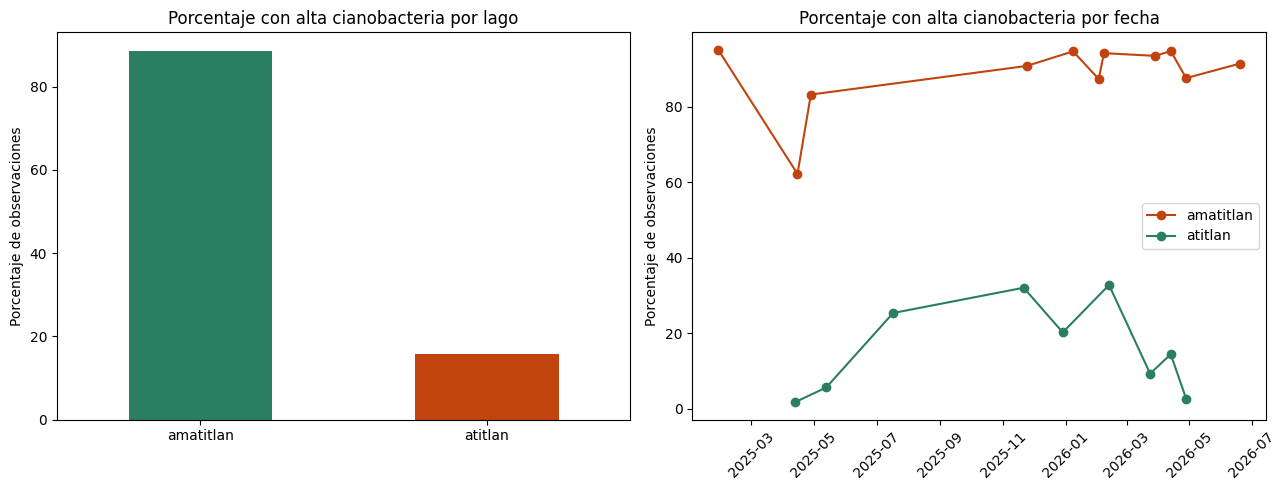

In [10]:
proporcion_por_lago = dataset_ml.groupby("lago")["alta_cianobacteria"].mean() * 100
print("Porcentaje de observaciones con alta cianobacteria, por lago:")
print(proporcion_por_lago, "\n")

proporcion_por_fecha = dataset_ml.groupby(["lago", "fecha"])["alta_cianobacteria"].mean() * 100
print("Porcentaje de observaciones con alta cianobacteria, por lago y fecha:")
print(proporcion_por_fecha)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

proporcion_por_lago.plot(kind="bar", ax=axes[0], color=["#2a7f62", "#c1440e"])
axes[0].set_title("Porcentaje con alta cianobacteria por lago")
axes[0].set_ylabel("Porcentaje de observaciones")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

colores_lago = {"atitlan": "#2a7f62", "amatitlan": "#c1440e"}
for lago, serie in proporcion_por_fecha.groupby(level=0):
    fechas = serie.index.get_level_values("fecha")
    axes[1].plot(fechas, serie.values, marker="o", label=lago, color=colores_lago[lago])
axes[1].set_title("Porcentaje con alta cianobacteria por fecha")
axes[1].set_ylabel("Porcentaje de observaciones")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.savefig(DATA_DIR / "distribucion_variable_respuesta.png", dpi=150)
plt.show()

### Ejercicio 2.4

A nivel global la proporción quedó en 25.0 por ciento clase 1 contra 75.0 por ciento clase 0, un desbalance moderado y esperado porque el corte se fijó en el percentil 75. Pero al desagregar por lago aparece un desbalance mucho más fuerte y en direcciones opuestas: en Amatitlán el 88.6 por ciento de las observaciones caen en alta cianobacteria, mientras que en Atitlán solo el 15.8 por ciento lo hace. Esto confirma, con la variable respuesta ya binarizada, la diferencia entre lagos que se observó en la Parte I: Amatitlán se mantiene consistentemente por encima del umbral global casi todo el tiempo, y Atitlán casi siempre por debajo, con algunas fechas puntuales donde sube bastante, por ejemplo 2025-11-21 y 2026-02-12 superan 30 por ciento.

Un desbalance de este tipo, y sobre todo tan distinto entre lagos, tiene consecuencias directas sobre el entrenamiento y la evaluación:

Entrenamiento: los modelos tienden a favorecer la clase mayoritaria de cada conjunto, porque minimizar el error total sin ponderar clases ya da buen resultado prediciendo casi siempre la clase dominante. Esto se compensa típicamente con class_weight balanceado, sobremuestreo de la clase minoritaria o submuestreo de la mayoritaria, y es especialmente relevante en el Ejercicio 7, donde se entrena con un lago y se evalúa con el otro, porque la clase mayoritaria de entrenamiento puede ser la minoritaria en el lago de evaluación.


### Ejercicio 2.5

La variable respuesta alta_cianobacteria se construyó directamente a partir de cyano, y cyano a su vez se calcula únicamente con B04 y B05. Por lo tanto, B04, B05 y cyano no pueden usarse como predictores en el Ejercicio 3: si se incluyeran, el modelo tendría acceso directo o casi directo a la información que define la propia respuesta, lo que produciría métricas artificialmente altas en entrenamiento y en la evaluación interna, pero que no se sostendrían con datos verdaderamente nuevos. Estas tres columnas se mantienen en el dataset limpio como referencia y para poder reconstruir cyano más adelante, por ejemplo para los mapas predictivos del Ejercicio 9, pero quedan fuera del conjunto de predictores.